<a href="https://colab.research.google.com/github/Mahmood-Anaam/flaird/blob/end-codex-work/notebooks/flaird_dataset_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FLAIRD dataset preparation

Leakage-safe cleaning, blending, balancing, forensic extraction, and private Hub publication for RAID + PAN26.

## Configuration

In [ ]:
import os
from google.colab import userdata
from huggingface_hub import login

HF_USERNAME = "MahmoodAnaam"
HF_TOKEN = userdata.get("HF_TOKEN")
login(HF_TOKEN)

os.environ["HF_USERNAME"] = HF_USERNAME
os.environ["HF_TOKEN"] = HF_TOKEN

## Imports

In [ ]:
!pip install pystylometry[all] --q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.7/285.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 52.4 MB/s eta 0:00:00


In [ ]:
import os
from datasets import load_dataset, ClassLabel, DatasetDict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## PAN-2026 Dataset

Load the official PAN-2026 training and validation splits from the HuggingFace Hub.

In [ ]:
pan26_train = load_dataset(f"{HF_USERNAME}/pan26",split="train")
pan26_validation = load_dataset(f"{HF_USERNAME}/pan26",split="validation")

In [ ]:
pan26_train

Dataset({
    features: ['id', 'text', 'model', 'label', 'genre'],
    num_rows: 23707
})

In [ ]:
pan26_train.column_names

['id', 'text', 'model', 'label', 'genre']

**Training split** — 23,707 samples across 5 columns: `id`, `text`, `model`, `label`, `genre`.

In [ ]:
pan26_validation

Dataset({
    features: ['id', 'text', 'model', 'label', 'genre'],
    num_rows: 3589
})

In [ ]:
pan26_validation.column_names

['id', 'text', 'model', 'label', 'genre']

**Validation split** — 3,589 samples with the same schema.

Cast the `label` column to `ClassLabel`.

In [ ]:
class_labels = ClassLabel(names=["human", "machine"], num_classes=2)
pan26_train = pan26_train.cast_column("label", class_labels)
pan26_validation = pan26_validation.cast_column("label", class_labels)

In [ ]:
pan26_train = pan26_train.add_column(name="dataset", column=["pan26-train"] * len(pan26_train))
pan26_validation = pan26_validation.add_column(name="dataset", column=["pan26-validation"] * len(pan26_validation))

In [ ]:
pan26_train , pan26_validation

(Dataset({
     features: ['id', 'text', 'model', 'label', 'genre', 'dataset'],
     num_rows: 23707
 }),
 Dataset({
     features: ['id', 'text', 'model', 'label', 'genre', 'dataset'],
     num_rows: 3589
 }))

## RAID Dataset

The RAID benchmark ([Dugan et al., 2024](https://arxiv.org/abs/2406.07441)) contains 5.6 M rows generated by 11 LLMs across 11 domains and 12 adversarial attack types.

Column schema after loading: `id`, `adv_source_id`, `source_id`, `model`, `decoding`, `repetition_penalty`, `attack`, `domain`, `title`, `prompt`, `generation`.

`raid_test` is held out and never enters preparation. It has no labels and is retained solely for RAID leaderboard prediction.

In [ ]:
raid_train = load_dataset("liamdugan/raid","raid",split="train")
raid_test = load_dataset("liamdugan/raid","raid_test",split="test")

In [ ]:
raid_train, raid_test

(Dataset({
     features: ['id', 'adv_source_id', 'source_id', 'model', 'decoding', 'repetition_penalty', 'attack', 'domain', 'title', 'prompt', 'generation'],
     num_rows: 5615820
 }),
 Dataset({
     features: ['id', 'generation'],
     num_rows: 672000
 }))

In [ ]:
raid_train.column_names, raid_test.column_names

(['id',
  'adv_source_id',
  'source_id',
  'model',
  'decoding',
  'repetition_penalty',
  'attack',
  'domain',
  'title',
  'prompt',
  'generation'],
 ['id', 'generation'])

Retain only the columns required for training; rename `generation` → `text` and `domain` → `genre` to align with the PAN-2026 schema.

In [ ]:
raid_train = raid_train.select_columns(["id", "generation", "model", "domain", "attack"])
raid_train = raid_train.rename_columns({"generation": "text", "domain": "genre"})
raid_train.column_names

['id', 'text', 'model', 'genre', 'attack']

Add integer `label` column: `0` = human, `1` = machine, mirroring the PAN-2026 convention.

In [ ]:
labels = [0 if model.lower() == "human" else 1 for model in raid_train["model"]]
raid_train = raid_train.add_column(name="label", column=labels)

In [ ]:
raid_train

Dataset({
    features: ['id', 'text', 'model', 'genre', 'attack', 'label'],
    num_rows: 5615820
})

Cast the `label` column to `ClassLabel`.

In [ ]:
class_labels = ClassLabel(names=["human", "machine"], num_classes=2)
raid_train = raid_train.cast_column("label", class_labels)

Casting the dataset:   0%|          | 0/5615820 [00:00<?, ? examples/s]

In [ ]:
raid_split = raid_train.train_test_split(
    test_size=0.10,
    stratify_by_column="label",
    seed=42,
)
raid_split

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'model', 'genre', 'attack', 'label'],
        num_rows: 5054238
    })
    test: Dataset({
        features: ['id', 'text', 'model', 'genre', 'attack', 'label'],
        num_rows: 561582
    })
})

In [ ]:
raid_train = raid_split['train']
raid_validation = raid_split['test']

In [ ]:
raid_train, raid_validation

(Dataset({
     features: ['id', 'text', 'model', 'genre', 'attack', 'label'],
     num_rows: 5054238
 }),
 Dataset({
     features: ['id', 'text', 'model', 'genre', 'attack', 'label'],
     num_rows: 561582
 }))

In [ ]:
raid_train = raid_train.add_column(name="dataset", column=["raid-train"] * len(raid_train))
raid_validation = raid_validation.add_column(name="dataset", column=["raid-validation"] * len(raid_validation))

Flattening the indices:   0%|          | 0/5054238 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/561582 [00:00<?, ? examples/s]

In [ ]:
raid_train, raid_validation

(Dataset({
     features: ['id', 'text', 'model', 'genre', 'attack', 'label', 'dataset'],
     num_rows: 5054238
 }),
 Dataset({
     features: ['id', 'text', 'model', 'genre', 'attack', 'label', 'dataset'],
     num_rows: 561582
 }))

## Flaird Dataset

In [ ]:
import datasets

flaird_train = datasets.concatenate_datasets([pan26_train, raid_train])
flaird_validation = datasets.concatenate_datasets([pan26_validation, raid_validation])

flaird_train, flaird_validation

(Dataset({
     features: ['id', 'text', 'model', 'label', 'genre', 'dataset', 'attack'],
     num_rows: 5077945
 }),
 Dataset({
     features: ['id', 'text', 'model', 'label', 'genre', 'dataset', 'attack'],
     num_rows: 565171
 }))

In [ ]:
"""Deterministic forensic-linguistic features used by FLAIRD."""

import math
import re
from dataclasses import dataclass

import numpy as np
from pystylometry.character import compute_character_metrics
from pystylometry.lexical import (
    compute_function_words,
    compute_hapax_ratios,
    compute_mtld,
    compute_ttr,
    compute_yule,
)
from pystylometry.ngrams import (
    compute_character_bigram_entropy,
    compute_word_bigram_entropy,
)


FEATURE_NAMES = (
    "ttr", "root_ttr", "log_ttr", "mtld", "yule_k", "yule_i",
    "hapax_ratio", "dis_hapax_ratio", "sichel_s", "honore_r",
    "determiner_ratio", "preposition_ratio", "conjunction_ratio", "pronoun_ratio",
    "auxiliary_ratio", "function_word_ratio", "function_word_diversity",
    "avg_word_length", "avg_sentence_length_chars", "punctuation_density",
    "punctuation_variety", "vowel_consonant_ratio", "digit_ratio", "uppercase_ratio",
    "whitespace_ratio", "character_bigram_entropy", "word_bigram_entropy",
    "sentence_length_cv", "paragraph_length_cv", "word_burstiness", "repeated_bigram_ratio",
    "question_density", "exclamation_density", "quote_density", "newline_density",
)


def _finite(value: object) -> float:
    try:
        number = float(value)
        return number if math.isfinite(number) else 0.0
    except (TypeError, ValueError):
        return 0.0


def _cv(values: list[int]) -> float:
    return float(np.std(values) / np.mean(values)) if values and np.mean(values) else 0.0


@dataclass
class ForensicFeatureExtractor:
    """Extract a fixed, ordered vector; raw text evidence is never normalized away."""

    def extract_dict(self, text: str) -> dict[str, float]:
        text = text or ""
        words = re.findall(r"\b[\w'-]+\b", text.lower())
        sentences = [s for s in re.split(r"[.!?]+", text) if s.strip()]
        paragraphs = [p for p in re.split(r"\n\s*\n", text) if p.strip()]
        try:
            ttr, mtld, yule = compute_ttr(text), compute_mtld(text), compute_yule(text)
            hapax, function = compute_hapax_ratios(text), compute_function_words(text)
            char = compute_character_metrics(text)
            char_entropy = compute_character_bigram_entropy(text)
            word_entropy = compute_word_bigram_entropy(text)
        except (ValueError, ZeroDivisionError):
            # Pystylometry intentionally rejects some extremely short inputs.
            ttr = mtld = yule = hapax = function = char = char_entropy = word_entropy = None

        def attr(obj: object, name: str) -> float:
            return _finite(getattr(obj, name, 0.0))

        counts: dict[tuple[str, ...], int] = {}
        bigrams = list(zip(words, words[1:]))
        for item in bigrams:
            counts[item] = counts.get(item, 0) + 1
        frequencies = list({word: words.count(word) for word in set(words)}.values())
        values = {
            "ttr": attr(ttr, "ttr"), "root_ttr": attr(ttr, "root_ttr"),
            "log_ttr": attr(ttr, "log_ttr"), "mtld": attr(mtld, "mtld_average"),
            "yule_k": attr(yule, "yule_k"), "yule_i": attr(yule, "yule_i"),
            "hapax_ratio": attr(hapax, "hapax_ratio"),
            "dis_hapax_ratio": attr(hapax, "dis_hapax_ratio"),
            "sichel_s": attr(hapax, "sichel_s"), "honore_r": attr(hapax, "honore_r"),
            "determiner_ratio": attr(function, "determiner_ratio"),
            "preposition_ratio": attr(function, "preposition_ratio"),
            "conjunction_ratio": attr(function, "conjunction_ratio"),
            "pronoun_ratio": attr(function, "pronoun_ratio"),
            "auxiliary_ratio": attr(function, "auxiliary_ratio"),
            "function_word_ratio": attr(function, "total_function_word_ratio"),
            "function_word_diversity": attr(function, "function_word_diversity"),
            "avg_word_length": attr(char, "avg_word_length"),
            "avg_sentence_length_chars": attr(char, "avg_sentence_length_chars"),
            "punctuation_density": attr(char, "punctuation_density"),
            "punctuation_variety": attr(char, "punctuation_variety"),
            "vowel_consonant_ratio": attr(char, "vowel_consonant_ratio"),
            "digit_ratio": attr(char, "digit_ratio"), "uppercase_ratio": attr(char, "uppercase_ratio"),
            "whitespace_ratio": attr(char, "whitespace_ratio"),
            "character_bigram_entropy": attr(char_entropy, "entropy"),
            "word_bigram_entropy": attr(word_entropy, "entropy"),
            "sentence_length_cv": _cv([len(s.split()) for s in sentences]),
            "paragraph_length_cv": _cv([len(p.split()) for p in paragraphs]),
            "word_burstiness": _cv(frequencies),
            "repeated_bigram_ratio": sum(v > 1 for v in counts.values()) / max(1, len(counts)),
            "question_density": text.count("?") / max(1, len(sentences)),
            "exclamation_density": text.count("!") / max(1, len(sentences)),
            "quote_density": (text.count('"') + text.count("“") + text.count("”")) / max(1, len(words)),
            "newline_density": text.count("\n") / max(1, len(words)),
        }
        return {name: _finite(values[name]) for name in FEATURE_NAMES}

    def __call__(self, text: str) -> list[float]:
        values = self.extract_dict(text)
        return [values[name] for name in FEATURE_NAMES]


In [ ]:
import re

flaird_name_dct = {
    "GPT": ["gpt3", "gpt2","chatgpt", "gpt4","gpt-3.5-turbo","gpt-4o-mini","gpt-4o","o3-mini","gpt-4.5-preview","gpt-4-turbo-paraphrase","gpt-4-turbo"],
    "Meta-LLaMA": ["llama-chat","llama-2-7b-chat","llama-2-70b-chat","llama-3.3-70b-instruct","llama-3.1-8b-instruct"],
    "Mistral": ["mistral", "mistral-chat","ministral-8b-instruct-2410","mistral-7b-instruct-v0.2","mixtral-8x7b-instruct-v0.1"],
    "Gemini": ["gemini-2.0-flash","gemini-1.5-pro","gemini-pro","gemini-pro-paraphrase"],
    "DeepSeek": ["deepseek-r1-distill-qwen-32b"],
    "Falcon": ["falcon3-10b-instruct"],
    "Bison": ["text-bison-002"],
    "Qwen": ["qwen1.5-72b-chat-8bit"],
    "MPT": ["mpt", "mpt-chat"],
    "Cohere": ["cohere", "cohere-chat"],
    "human": ["human"],
}

flaird_model_set = {
    "GPT": 0,
    "Meta-LLaMA": 1,
    "MPT": 2,
    "Cohere": 3,
    "Mistral": 4,
    "Gemini":5,
    "DeepSeek": 6,
    "Falcon": 7,
    "Bison": 8,
    "Qwen": 9,
    "human": 10,
}

MODEL_TO_FAMILY = {
    model: family
    for family, models in flaird_name_dct.items()
    for model in models
}

def generator_label_for_model(model: str | None) -> int:
  family = MODEL_TO_FAMILY.get((model).lower())
  return flaird_model_set[family]


def add_features(batch):
  feature_extractor = ForensicFeatureExtractor()
  texts = batch['text']
  batch["forensic_features"] = [feature_extractor(text) for text in texts]
  return batch

def preprocess(text):
  EMAIL_PATTERN = re.compile(r"(?i)\b[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,}\b")
  USER_MENTION_PATTERN = re.compile(r"@[A-Za-z0-9_-]+")
  PHONE_PATTERN = re.compile(r"(\+?\d{1,3})?[\s\*\.-]?\(?\d{1,4}\)?[\s\*\.-]?\d{2,4}[\s\*\.-]?\d{2,6}")
  text = re.sub(EMAIL_PATTERN, "[EMAIL]", text)
  text = re.sub(USER_MENTION_PATTERN, "[USER]", text)
  text = re.sub(PHONE_PATTERN, " [PHONE]", text).replace("  [PHONE]", " [PHONE]")
  return text


def normalize_batch(batch):
  batch["text"] = [preprocess(text) for text in batch["text"]]
  models = batch["model"]
  batch["model_family"] = [MODEL_TO_FAMILY.get(model) for model in batch["model"]]
  batch["generator_label"] = [generator_label_for_model(model) for model in batch["model"]]
  return batch

In [ ]:
flaird_validation = flaird_validation.map(normalize_batch, batched=True, batch_size=2000, num_proc=4)
flaird_validation

Map (num_proc=4):   0%|          | 0/565171 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'text', 'model', 'label', 'genre', 'dataset', 'attack', 'model_family', 'generator_label'],
    num_rows: 565171
})

In [ ]:
flaird_train = flaird_train.map(normalize_batch, batched=True, batch_size=2000, num_proc=4)
flaird_train

Map (num_proc=4):   0%|          | 0/5077945 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'text', 'model', 'label', 'genre', 'dataset', 'attack', 'model_family', 'generator_label'],
    num_rows: 5077945
})

In [ ]:
class_generator_labels = ClassLabel(names=list(flaird_model_set.keys()), num_classes=len(flaird_model_set))
flaird_train = flaird_train.cast_column("generator_label", class_generator_labels)
flaird_validation = flaird_validation.cast_column("generator_label", class_generator_labels)

Casting the dataset:   0%|          | 0/5077945 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/565171 [00:00<?, ? examples/s]

In [ ]:
flaird_train, flaird_validation

In [ ]:
flaird_train = flaird_train.select_columns([
    "id",
    "dataset",
    "text",
    "genre",
    "attack",
    "model",
    "model_family",
    "label",
    "generator_label",
])

flaird_validation = flaird_validation.select_columns([
    "id",
    "dataset",
    "text",
    "genre",
    "attack",
    "model",
    "model_family",
    "label",
    "generator_label",
])

flaird_train, flaird_validation

(Dataset({
     features: ['id', 'dataset', 'text', 'genre', 'attack', 'model', 'model_family', 'label', 'generator_label'],
     num_rows: 5077945
 }),
 Dataset({
     features: ['id', 'dataset', 'text', 'genre', 'attack', 'model', 'model_family', 'label', 'generator_label'],
     num_rows: 565171
 }))

## Exploratory Data Analysis

In [ ]:
flaird_train_df = flaird_train.to_pandas()
flaird_validation_df = flaird_validation.to_pandas()

In [ ]:
flaird_train_df.head()

,id,dataset,text,genre,attack,model,model_family,label,generator_label,text_len
0,ea468d03-1973-5039-86b2-ff225bb92c4e,pan26-train,"Duke Ellington, a titan of jazz, revolutionize...",essays,None,falcon3-10b-instruct,Falcon,1,7,2480
1,0d05f269-6d67-521d-9b5d-cc18f482c6c1,pan26-train,I reflected on the shifting dynamics of media ...,essays,None,o3-mini,GPT,1,0,3395
2,c2ec79f3-da80-58f8-bef0-3e0ea7ab072f,pan26-train,"In F. Scott Fitzgerald's ""The Great Gatsby,"" t...",essays,None,gpt-4o,GPT,1,0,3288
3,4ad37c58-0bb7-536b-997d-cfccabd0d094,pan26-train,I still chuckle when I think about that time I...,essays,None,deepseek-r1-distill-qwen-32b,DeepSeek,1,6,2347
4,07747b0c-5051-5e0d-8096-b4d4ed8bd98e,pan26-train,"Yoga, originating in ancient India, encompasse...",essays,None,gemini-2.0-flash,Gemini,1,5,3588


In [ ]:
flaird_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5077945 entries, 0 to 5077944
Data columns (total 10 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   id               object
 1   dataset          object
 2   text             object
 3   genre            object
 4   attack           object
 5   model            object
 6   model_family     object
 7   label            int64 
 8   generator_label  int64 
 9   text_len         int64 
dtypes: int64(3), object(7)
memory usage: 387.4+ MB


In [ ]:
flaird_validation_df.head()

,id,dataset,text,genre,attack,model,model_family,label,generator_label,text_len
0,7caf42b9-fd48-5e97-a0d0-0ae28a1f9603,pan26-validation,"In William Faulkner's ""The Sound and the Fury,...",essays,None,gpt-4o,GPT,1,0,3693
1,28b61fc4-e82b-5cf8-bc34-1ecdb7182993,pan26-validation,"Manipulation, a profound and pervasive theme i...",essays,None,gpt-4.5-preview,GPT,1,0,3780
2,22398c76-da72-5724-973e-0981b8e9cbee,pan26-validation,Edna's journey is a testament to her rebellion...,essays,None,llama-3.3-70b-instruct,Meta-LLaMA,1,1,3133
3,3cd1e50d-e1f0-5f8f-bfb8-0b8a6048bcaa,pan26-validation,There are three main aspects of the gun contro...,essays,None,human,human,0,10,3099
4,6e5745a6-0335-50cc-bdf0-fa0e1fee7518,pan26-validation,During the Portuguese colonial period in Angol...,essays,None,gpt-4o,GPT,1,0,3135


In [ ]:
flaird_validation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565171 entries, 0 to 565170
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   id               565171 non-null  object
 1   dataset          565171 non-null  object
 2   text             565171 non-null  object
 3   genre            565171 non-null  object
 4   attack           561582 non-null  object
 5   model            565171 non-null  object
 6   model_family     565171 non-null  object
 7   label            565171 non-null  int64 
 8   generator_label  565171 non-null  int64 
 9   text_len         565171 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 43.1+ MB


**Label distribution**

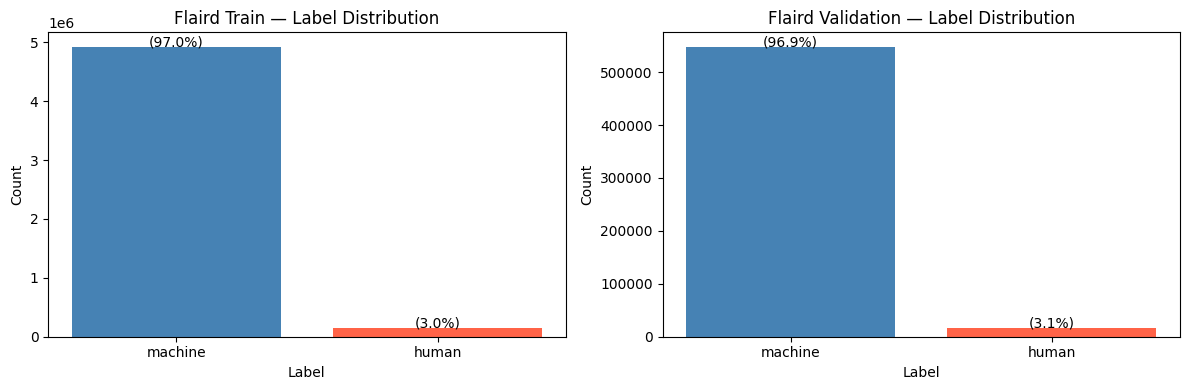

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes, [flaird_train_df, flaird_validation_df], ['Train', 'Validation']):
    counts = df['label'].map({0: "human", 1: "machine"}).value_counts()
    ax.bar(counts.index, counts.values, color=['steelblue', 'tomato'])
    ax.set_title(f'Flaird {title} — Label Distribution')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    for j, (lbl, cnt) in enumerate(counts.items()):
        ax.text(j, cnt + 20, f'({cnt/len(df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

**Genre distribution**

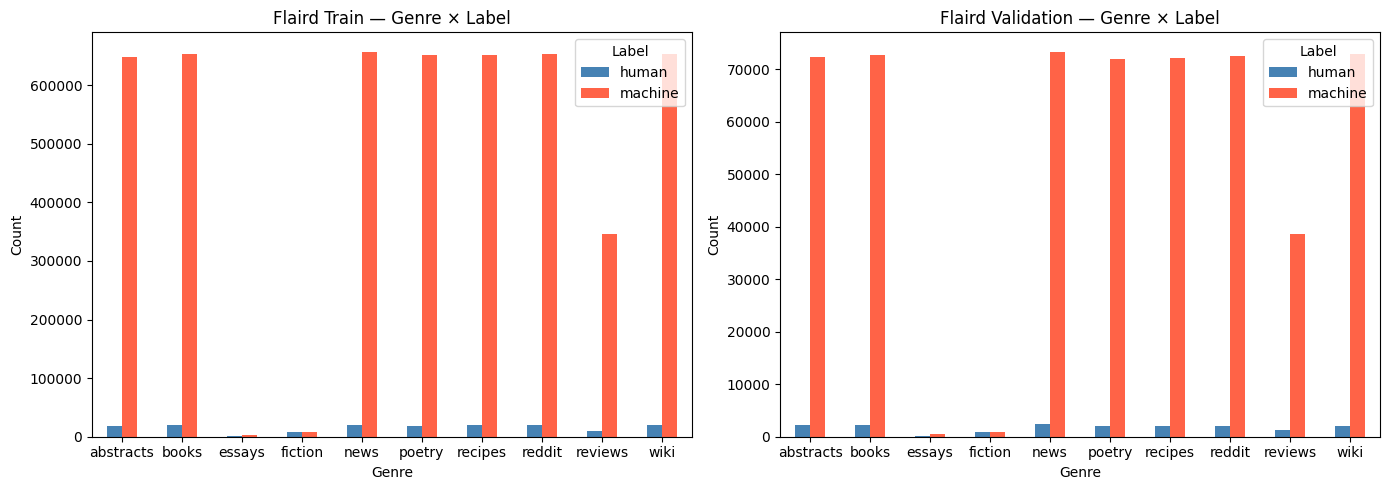

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes, [flaird_train_df, flaird_validation_df], ['Train', 'Validation']):
    genre_label = df.groupby(['genre', df['label'].map({0: "human", 1: "machine"})]).size().unstack(fill_value=0)
    genre_label.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
    ax.set_title(f'Flaird {title} — Genre × Label')
    ax.set_xlabel('Genre')
    ax.set_ylabel('Count')
    ax.legend(title='Label')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**AI model by family distribution (training)**

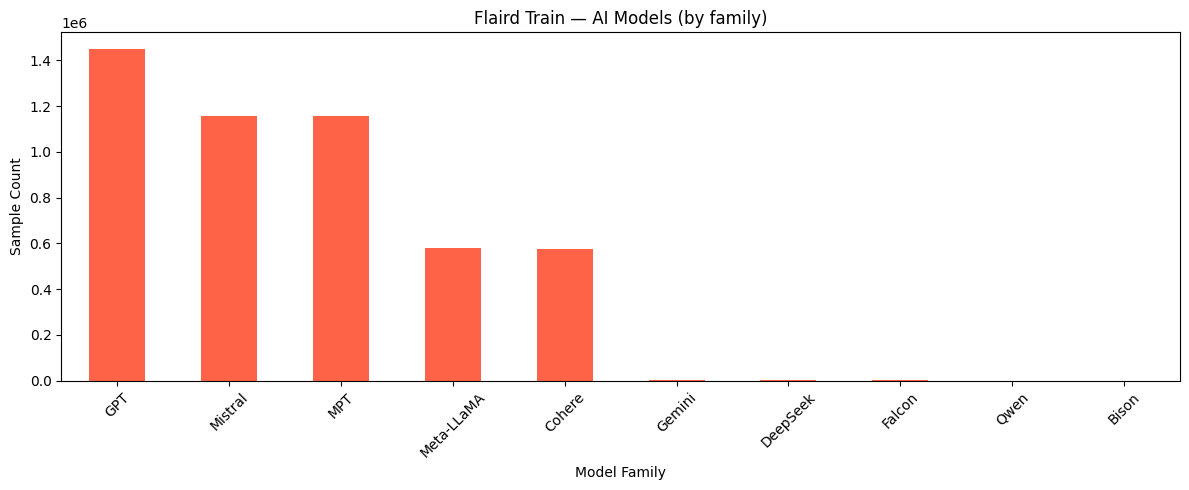

In [ ]:
model_counts = flaird_train_df[flaird_train_df['label'] == 1]['model_family'].value_counts()
fig, ax = plt.subplots(figsize=(12, 5))
model_counts.plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Flaird Train — AI Models (by family)')
ax.set_xlabel('Model Family')
ax.set_ylabel('Sample Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
model_counts

,count
model_family,
GPT,1450356
Mistral,1156816
MPT,1155473
Meta-LLaMA,579466
Cohere,577318
Gemini,2692
DeepSeek,901
Falcon,879
Qwen,271


**Text length distribution**

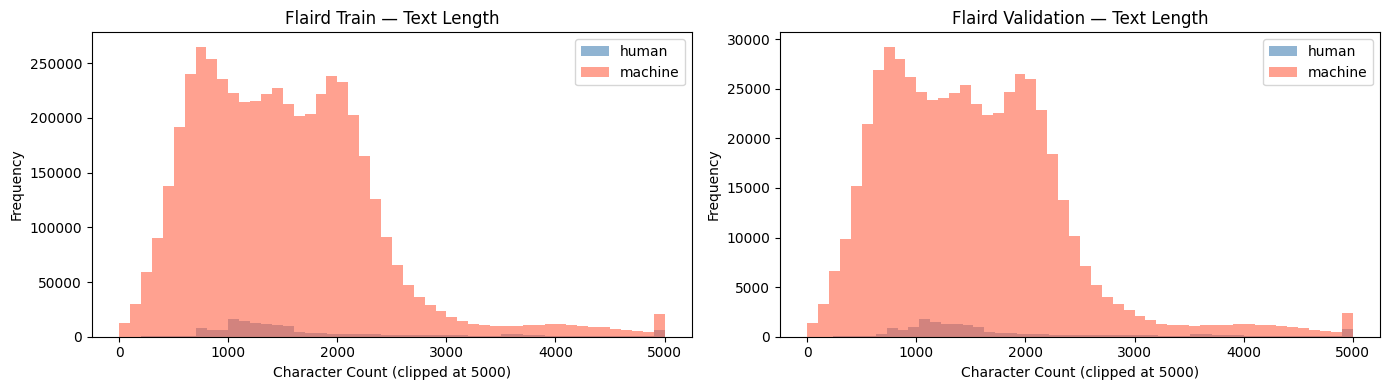

In [ ]:
for df, name in [(flaird_train_df, 'Train'), (flaird_validation_df, 'Validation')]:
    df['text_len'] = df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, title in zip(axes, [flaird_train_df, flaird_validation_df], ['Train', 'Validation']):
    for lbl, color in [(0, 'steelblue'), (1, 'tomato')]:
        subset = df[df['label'] == lbl]['text_len']
        ax.hist(subset.clip(0, 5000), bins=50, alpha=0.6,
                color=color, label={0: "human", 1: "machine"}[lbl])
    ax.set_title(f'Flaird {title} — Text Length')
    ax.set_xlabel('Character Count (clipped at 5000)')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.show()

## Features

In [ ]:
flaird_train_features = flaird_train.map(add_features, batched=True, batch_size=2000, num_proc=4)
flaird_train_features

Map (num_proc=4):   0%|          | 0/5077945 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'dataset', 'text', 'genre', 'attack', 'model', 'model_family', 'label', 'generator_label', 'forensic_features'],
    num_rows: 5077945
})

In [ ]:
flaird_validation_features = flaird_validation.map(add_features, batched=True, batch_size=2000, num_proc=4)
flaird_validation_features

Map (num_proc=4):   0%|          | 0/565171 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'dataset', 'text', 'genre', 'attack', 'model', 'model_family', 'label', 'generator_label', 'forensic_features'],
    num_rows: 565171
})

## Push to hub

In [ ]:
flaird_train.push_to_hub(f"{HF_USERNAME}/flaird-raid-pan26", config_name="flaird_train", split="train")
flaird_validation.push_to_hub(f"{HF_USERNAME}/flaird-raid-pan26", config_name="flaird_validation", split="validation")
raid_test.push_to_hub(f"{HF_USERNAME}/flaird-raid-pan26", config_name="raid_test", split="test")

In [ ]:
flaird_train_features.push_to_hub(f"{HF_USERNAME}/flaird-raid-pan26", config_name="flaird_train_features", split="train")
flaird_validation_features.push_to_hub(f"{HF_USERNAME}/flaird-raid-pan26", config_name="flaird_validation_features", split="validation")

## Summary

This notebook details the preparation of the FLAIRD dataset, which combines the PAN-2026 and RAID datasets for AI-generated text detection.

**Key Steps Performed:**
*   Loaded and processed PAN-2026 and RAID datasets, including column selection, renaming, and label casting.
*   Combined these into unified `flaird_train` and `flaird_validation` datasets.
*   Implemented text preprocessing (email, user mention, phone number normalization) and mapped AI models to broader families.
*   Extracted forensic linguistic features using `pystylometry` for both training and validation sets.
*   Conducted Exploratory Data Analysis (EDA) on the combined datasets.
*   Pushed the processed datasets and features to the Hugging Face Hub.

**Key Findings from EDA:**
*   **Label Imbalance**: The dataset is heavily skewed towards 'machine'-generated text (approximately 97%) compared to 'human' text.
*   **Genre Distribution**: Machine-generated samples are prevalent across all genres.
*   **Model Distribution**: GPT, Mistral, and MPT model families constitute the majority of AI-generated content in the training set.
*   **Text Length**: Both human and machine texts typically range from 1000-2000 characters, with machine texts showing a wider distribution.